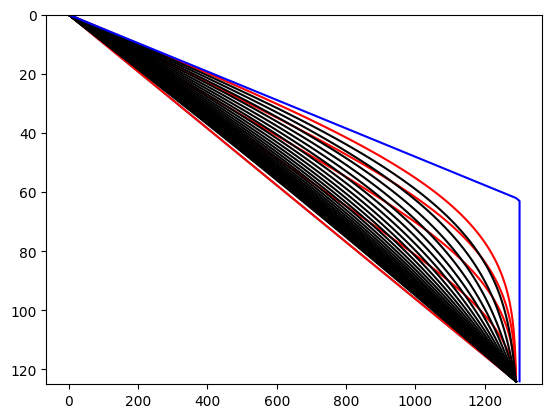

In [14]:
import numpy as np
import matplotlib.pyplot as plt


rhom = 3300.0 # Densidade de referência do manto
rhoc = 2700.0 # Densidade de referência da crosta
rhow = 1000.0 # Densidade da água

alpha = 3.28E-5 # Coeficiente de expansão volumétrico (1/K)

hc = 35000.0 # Espessura original da crosta
a = 125000.0 # Espessura original da litosfera (crosta + manto lito.)


beta = 2.0


T1 = 1300.0 # Temperatura na base da litosfera
T0 = 0.0 # Temperatura na superfície

dz = 1000.0
z = np.arange(0.0,a,dz)

T = z*T1/a
T[T>T1] = T1

t_rift = 20.0E6 # Duração da fase rifte em anos

plt.plot(T,z/1000)
plt.ylim(125,0)

kappa = 1.0E-6 # m2/s (Difusividade térmica)
t = -t_rift
dt = 1000.0
t_print = t
seg_por_ano = 365.*24.*60.*60.0
fac = dt*seg_por_ano*kappa/dz**2

G = np.log(beta)/(t_rift*seg_por_ano)



fluxo_termico = []
tempo = []
subsidencia = []
k = 4.0 # W/(m.K) condutividade térmica

Toriginal = np.copy(T)

tmax = 160.0E6
cor = "r"
for t in np.arange(-t_rift,tmax,dt):
  if t>=t_print:
    plt.plot(T,z/1000,cor)
    t_print+=5.0E6

  T[1:-1] += fac*(T[2:]-2*T[1:-1]+T[:-2]) + \
              dt*seg_por_ano*G*z[1:-1]*(T[2:]-T[:-2])/(2*dz)

  if (t>0):
    G=0.0
    cor = "k"


TMck = T1*beta*z/a
TMck[TMck>T1]=T1

plt.plot(TMck,z/1000,"b")

g = 10.0 # gravidade (m/s2)
rhom = 3300.0 # densidade do manto (kg/m3)




In [ ]:
def jarvis(t_rift,beta):
  rhom = 3300.0 # Densidade de referência do manto
  rhoc = 2700.0 # Densidade de referência da crosta
  rhow = 1000.0 # Densidade da água

  alpha = 3.28E-5 # Coeficiente de expansão volumétrico (1/K)
  T1 = 1300.0 # Temperatura do manto astenosférico (oC)

  hc = 35000.0 # Espessura original da crosta
  a = 125000.0 # Espessura original da litosfera (crosta + manto lito.)


  T1 = 1300.0 # Temperatura na base da litosfera
  T0 = 0.0 # Temperatura na superfície

  dz = 1000.0
  z = np.arange(0.0,a,dz)

  T = z*T1/a
  T[T>T1] = T1

  kappa = 1.0E-6 # m2/s (Difusividade térmica)
  t = -t_rift
  dt = 1000.0
  t_print = t
  seg_por_ano = 365.*24.*60.*60.0
  fac = dt*seg_por_ano*kappa/dz**2

  G = np.log(beta)/(t_rift*seg_por_ano)



  fluxo_termico = []
  tempo = []
  subsidencia = []
  k = 4.0 # W/(m.K) condutividade térmica

  Toriginal = np.copy(T)

  fluxo_termico = []
  tempo = []

  tmax = 160.0E6
  cor = "r"
  for t in np.arange(-t_rift,tmax,dt):
    if t>=t_print:
      fluxo_termico = np.append(fluxo_termico,-k*(T[0]-T[1]/dz))
      tempo = np.append(tempo,t)
      t_print+=5.0E6

    T[1:-1] += fac*(T[2:]-2*T[1:-1]+T[:-2]) + \
                dt*seg_por_ano*G*z[1:-1]*(T[2:]-T[:-2])/(2*dz)

    if (t>0):
      G=0.0
      cor = "k"

  return(tempo,fluxo_termico)






In [ ]:
t40,q40 = jarvis(40.0E6,2.0)
t20,q20 = jarvis(20.0E6,2.0)
t5,q5 = jarvis(5.0E6,2.0)


Text(0.5, 0, 'Tempo (Ma)')

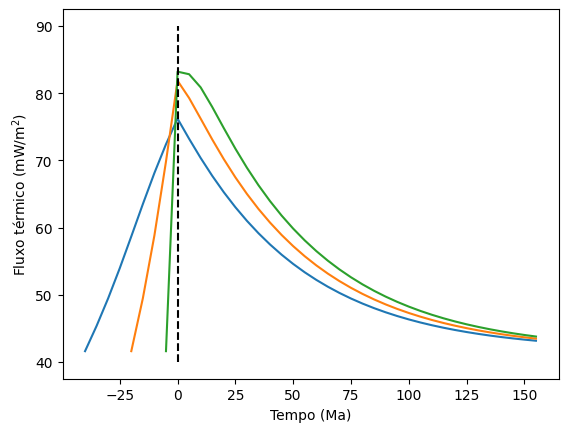

In [ ]:
plt.plot(t40/1.0E6,q40*1000)
plt.plot(t20/1.0E6,q20*1000)
plt.plot(t5/1.0E6,q5*1000)

plt.plot([0,0],[40,90],"k--")

plt.ylabel("Fluxo térmico (mW/m$^2$)")
plt.xlabel("Tempo (Ma)")